In [9]:
import uproot
import dask_awkward as dak
import glob
import numpy as np
import awkward as ak
import vector
import numpy as np
import glob
import os

In [ ]:
data_files = glob.glob("/home/aegis/ether/Research_HEP/Dataset_ver2/Data/reduce_root/*/run*/root_*.root")

mc_files = {
    "Diboson": glob.glob("/home/aegis/ether/Research_HEP/Dataset_ver3/MC/reduce_root/Diboson/*/root_*.root"),
    "Multijet": glob.glob("/home/aegis/ether/Research_HEP/Dataset_ver3/MC/reduce_root/Multijet/*/root_*.root"),
    "Single_top": glob.glob("/home/aegis/ether/Research_HEP/Dataset_ver3/MC/reduce_root/Single_top/*/root_*.root"),
    "ttbar": glob.glob("/home/aegis/ether/Research_HEP/Dataset_ver3/MC/reduce_root/ttbar/*/root_*.root"),
    "Wjets": glob.glob("/home/aegis/ether/Research_HEP/Dataset_ver3/MC/reduce_root/Wjets/*/root_*.root"),
    "Zjets": glob.glob("/home/aegis/ether/Research_HEP/Dataset_ver3/MC/reduce_root/Zjets/*/root_*.root")
}

In [ ]:
import uproot
import awkward as ak
import vector
import numpy as np

# 1. SETUP
vector.register_awkward()

# --- CONFIGURATION ---
BRANCHES = [
    # Jets (Small-R)
    "AnalysisJetsAuxDyn_pt", "AnalysisJetsAuxDyn_eta", "AnalysisJetsAuxDyn_phi",
    "AnalysisJetsAuxDyn_NumTrkPt500", "AnalysisJetsAuxDyn_SumPtTrkPt500", "AnalysisJetsAuxDyn_EnergyPerSampling", "AnalysisJetsAuxDyn_NNJvtPass"
    # B-Tagging inputs
    "BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pb", 
    "BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pc", 
    "BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pu",
    # Large-R Jets
    "AnalysisLargeRJetsAuxDyn_pt", "AnalysisLargeRJetsAuxDyn_eta", "AnalysisLargeRJetsAuxDyn_phi",
    "AnalysisLargeRJetsAuxDyn_Tau1_wta", "AnalysisLargeRJetsAuxDyn_Tau2_wta", "AnalysisLargeRJetsAuxDyn_Tau3_wta",
    # Electrons
    "AnalysisElectronsAuxDyn_pt", "AnalysisElectronsAuxDyn_eta", "AnalysisElectronsAuxDyn_phi",
    "AnalysisElectronsAuxDyn_DFCommonElectronsLHTight",
    # Muons
    "AnalysisMuonsAuxDyn_pt", "AnalysisMuonsAuxDyn_eta", "AnalysisMuonsAuxDyn_phi",
    "AnalysisMuonsAuxDyn_quality", "AnalysisMuonsAuxDyn_muonType",
    # Taus
    "AnalysisTauJetsAuxDyn_JetDeepSetTight", "AnalysisTauJetsAuxDyn_pt", "AnalysisTauJetsAuxDyn_eta",
    # Metadata
    "MET_Core_AnalysisMETAuxDyn_sumet",
    "MET_Core_AnalysisMETAuxDyn_mpx",
    "MET_Core_AnalysisMETAuxDyn_mpy",
    "EventInfoAuxDyn_mcEventWeights"
]

# ---------------------------------------------------------
# 2. THE PROCESSING KERNEL
# ---------------------------------------------------------
def process_batch(batch):
    
    # --- A. CONSTRUCT OBJECTS ---
    
    # 1. PRE-PROCESSING JETS
    # Fix SumPtTrk: Shape is (Event, Jet, Vertex). Take index 0 (Primary Vertex).
    sum_pt_trk_pv = batch["AnalysisJetsAuxDyn_SumPtTrkPt500"][:, :, 0] / 1000.0
    n_tracks_pv   = batch["AnalysisJetsAuxDyn_NumTrkPt500"][:, :, 0]  # <--- NEW FIX HERE
    # Fix EnergyPerSampling: Shape is (Event, Jet, Sampling).
    # We only need the MAX and SUM per jet for the "Bad Jet" cleaning.
    # We calculate them HERE to avoid attaching the complex nested vector to the jet object.
    energy_raw = batch["AnalysisJetsAuxDyn_EnergyPerSampling"]
    
    # Calculate scalar properties (Depth 2: Event, Jet)
    # axis=-1 reduces the "Sampling" dimension
    energy_max = ak.max(energy_raw, axis=-1)
    energy_sum = ak.sum(energy_raw, axis=-1)

    # 2. ZIP JETS
    # Now everything going into the zip is exactly the same shape (Event, Jet)
    j = ak.zip({
        "pt": batch["AnalysisJetsAuxDyn_pt"] / 1000.0,
        "eta": batch["AnalysisJetsAuxDyn_eta"],
        "phi": batch["AnalysisJetsAuxDyn_phi"],
        "n_tracks": batch["AnalysisJetsAuxDyn_NumTrkPt500"],
        "sum_pt_trk": sum_pt_trk_pv, 
        # Attach the PRE-CALCULATED scalars
        "n_tracks": n_tracks_pv,    # <--- Using the sliced PV variable
        "E_max": energy_max,
        "E_sum": energy_sum,
        # B-Tag scores
        "pb": batch["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pb"],
        "pc": batch["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pc"],
        "pu": batch["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pu"],
    }, with_name="Momentum4D")

    # 3. Large-R Jets
    tau1 = batch["AnalysisLargeRJetsAuxDyn_Tau1_wta"]
    tau2 = batch["AnalysisLargeRJetsAuxDyn_Tau2_wta"]
    tau3 = batch["AnalysisLargeRJetsAuxDyn_Tau3_wta"]
    
    lj = ak.zip({
        "pt": batch["AnalysisLargeRJetsAuxDyn_pt"] / 1000.0,
        "eta": batch["AnalysisLargeRJetsAuxDyn_eta"],
        "phi": batch["AnalysisLargeRJetsAuxDyn_phi"],
        "tau21": np.where(tau1 > 0, tau2 / tau1, -99.0),
        "tau32": np.where(tau2 > 0, tau3 / tau2, -99.0)
    }, with_name="Momentum4D")

    # 4. Electrons & Muons
    e = ak.zip({
        "pt": batch["AnalysisElectronsAuxDyn_pt"] / 1000.0,
        "eta": batch["AnalysisElectronsAuxDyn_eta"],
        "phi": batch["AnalysisElectronsAuxDyn_phi"],
        "tight": batch["AnalysisElectronsAuxDyn_DFCommonElectronsLHTight"]
    }, with_name="Momentum4D")

    mu = ak.zip({
        "pt": batch["AnalysisMuonsAuxDyn_pt"] / 1000.0,
        "eta": batch["AnalysisMuonsAuxDyn_eta"],
        "phi": batch["AnalysisMuonsAuxDyn_phi"],
        "qual": batch["AnalysisMuonsAuxDyn_quality"],
        "type": batch["AnalysisMuonsAuxDyn_muonType"]
    }, with_name="Momentum4D")

    # --- B. OVERLAP REMOVAL (Standard Order) ---
    
    # 1. Electron-Muon
    
    if ak.any(ak.num(e) > 0) and ak.any(ak.num(mu) > 0):
        pair_e_mu = ak.cartesian({"e": e, "mu": mu}, nested=True)
        dr = pair_e_mu.e.deltaR(pair_e_mu.mu)
        mask_e = ~ak.any(dr < 0.01, axis=-1)
        e = ak.to_packed(e[mask_e])

    # 2. Jet-Electron
    if ak.any(ak.num(j) > 0) and ak.any(ak.num(e) > 0):
        pair_j_e = ak.cartesian({"j": j, "e": e}, nested=True)
        dr = pair_j_e.j.deltaR(pair_j_e.e)
        mask_j = ~ak.any(dr < 0.2, axis=-1)
        j = ak.to_packed(j[mask_j])

    # 3. Electron-Jet
    if ak.any(ak.num(e) > 0) and ak.any(ak.num(j) > 0):
        pair_e_j = ak.cartesian({"e": e, "j": j}, nested=True)
        dr = pair_e_j.e.deltaR(pair_e_j.j)
        mask_e = ~ak.any(dr < 0.4, axis=-1)
        e = ak.to_packed(e[mask_e])

    # 4. Muon-Jet
    if ak.any(ak.num(mu) > 0) and ak.any(ak.num(j) > 0):
        pair_mu_j = ak.cartesian({"mu": mu, "j": j}, nested=True)
        dr = pair_mu_j.mu.deltaR(pair_mu_j.j)
        mask_mu = ~ak.any(dr < 0.4, axis=-1)
        mu = ak.to_packed(mu[mask_mu])
    
    # 5. Jet-Muon (Ghost Removal)
    if ak.any(ak.num(j) > 0) and ak.any(ak.num(mu) > 0):
        pair_j_mu = ak.cartesian({"j": j, "mu": mu}, nested=True)
        dr = pair_j_mu.j.deltaR(pair_j_mu.mu)
        bad_jet_cond = (dr < 0.2) & (pair_j_mu.j.n_tracks < 3)
        mask_j = ~ak.any(bad_jet_cond, axis=-1)
        j = ak.to_packed(j[mask_j])

    # --- C. VETOES ---
    
    # 1. Electron Veto
    e_abs_eta = np.abs(e.eta)
    e_crack = (e_abs_eta < 1.37) | (e_abs_eta > 1.52)
    e_pass = (e.tight == 1) & (e.pt > 7) & (e_abs_eta < 2.47) & e_crack
    veto_ele = ak.sum(e_pass, axis=-1) == 0

    # 2. Muon Veto
    mu_pass = (mu.pt > 7) & (np.abs(mu.eta) < 2.5) 
    veto_mu = ak.sum(mu_pass, axis=-1) == 0

    # 3. Tau Veto 
    t_tight = batch["AnalysisTauJetsAuxDyn_JetDeepSetTight"]
    t_pt = batch["AnalysisTauJetsAuxDyn_pt"] / 1000.0
    t_eta = batch["AnalysisTauJetsAuxDyn_eta"]
    tau_pass = (t_tight == 1) & (t_pt > 20) & (np.abs(t_eta) < 2.5)
    veto_tau = ak.sum(tau_pass, axis=-1) == 0

    # 4. B-Jet Veto
    denom = (0.08 * j.pc) + ((1 - 0.08) * j.pu)
    score = np.log(j.pb / np.maximum(denom, 1e-10)) 
    n_bjets = ak.sum((score > 1.45) & (j.pt > 20), axis=-1)
    veto_bjet = n_bjets < 2

    # --- D. JET CLEANING & KINEMATICS ---
    
    met_soft_x = batch["MET_Core_AnalysisMETAuxDyn_mpx"][:, 0] / 1000.0
    met_soft_y = batch["MET_Core_AnalysisMETAuxDyn_mpy"][:, 0] / 1000.0

    masked_j = ak.mask(j, ak.num(j) > 0)

# 2. Pick the leading jet (still length 50,000)
    lead_jet = masked_j[:, 0]

    # 3. Perform calculations (Awkward propagates 'None' automatically)
    f_max = lead_jet.E_max / lead_jet.E_sum
    f_ch = lead_jet.sum_pt_trk / lead_jet.pt

    # 4. Create the boolean mask
    # This will be [True, False, None, True...] length 50,000
    is_bad_jet = (f_ch / f_max) > 0.0001

    # 5. Clean up: Treat 'None' as 'not a bad jet' (False)
    veto_cleaning = ~ak.fill_none(is_bad_jet, False)

    # Kinematics
    j_at_least_2 = ak.mask(j, ak.num(j) >= 2)

    # Now slicing [:, 0] and [:, 1] is safe. 
    # If the event is None, the result of the slice is also None.
    pt_cuts = (j_at_least_2.pt[:, 0] > 250) & (j_at_least_2.pt[:, 1] > 30)

    # Fill the None entries (the <2 jet events) with False
    pt_cuts = ak.fill_none(pt_cuts, False)
    
    # --- E. OUTPUT ---
    
    global_mask = veto_ele & veto_mu & veto_tau & veto_bjet & veto_cleaning & pt_cuts
    obj_px = (
        ak.sum(j.px[global_mask], axis=-1) +
        ak.sum(e.px[global_mask], axis=-1) +
        ak.sum(mu.px[global_mask], axis=-1)
            )

    obj_py = (
        ak.sum(j.py[global_mask], axis=-1) +
        ak.sum(e.py[global_mask], axis=-1) +
        ak.sum(mu.py[global_mask], axis=-1)
        )
    
    met_x = -(np.sum(obj_px) + met_soft_x)
    met_y = -(np.sum(obj_py) + met_soft_y)

    met = np.sqrt(met_x**2 + met_y**2)


    ht = ak.sum(j.pt, axis=-1)
    mask_cr = global_mask & (met > 250) & (met < 500) & (ht > 600)
    mask_sr = global_mask & (met > 600) & (ht > 600)

    def pack_data(mask):
        return {
            "MET": met[mask],
            "HT": ht[mask],
            "Ljet_pt": lj.pt[mask], 
            "Ljet_eta": lj.eta[mask],
            "Ljet_tau21": lj.tau21[mask],
            "Ljet_tau32": lj.tau32[mask]
        }

    return pack_data(mask_cr), pack_data(mask_sr)

# ---------------------------------------------------------
# 3. RUNNER (No Changes Needed)
# ---------------------------------------------------------
def run_analysis(file_list):
    print(f"Processing {len(file_list)} files...")
    cr_data = {"MET": [], "HT": [], "Ljet_pt": [], "Ljet_eta": [], "Ljet_tau21": [], "Ljet_tau32": []}
    sr_data = {"MET": [], "HT": [], "Ljet_pt": [], "Ljet_eta": [], "Ljet_tau21": [], "Ljet_tau32": []}

    iterator = uproot.iterate(
        {f: "CollectionTree" for f in file_list}, 
        expressions=BRANCHES,
        step_size=50000, 
        library="ak"
    )
    
    for i, batch in enumerate(iterator):
        res_cr, res_sr = process_batch(batch)
        for key in cr_data:
            cr_data[key].append(res_cr[key])
            sr_data[key].append(res_sr[key])
        # print(f"  Batch {i}: {len(batch)} evts -> CR:{len(res_cr['MET'])} / SR:{len(res_sr['MET'])}")

    final_cr = {k: ak.concatenate(v) for k, v in cr_data.items()}
    final_sr = {k: ak.concatenate(v) for k, v in sr_data.items()}
    return final_cr, final_sr

In [12]:
cr, sr = run_analysis(mc_files["Diboson"])

print(f"Final Selection: CR={len(cr['MET'])} events, SR={len(sr['MET'])} events")

Processing 24 files...
Final Selection: CR=204 events, SR=482 events


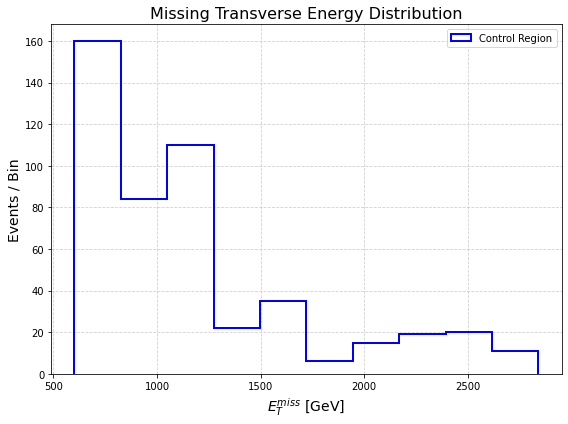

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'cr' is your dictionary containing the arrays
# We'll extract the MET array. 
# If it's an Awkward Array, .to_numpy() ensures compatibility.
met_data = sr['MET']

plt.figure(figsize=(8, 6))

# Define bins - usually better to set manually for physics data
# bins = np.linspace(400, 500, 20) 

# Plotting with the 'step' style common in HEP
plt.hist(met_data, histtype='step', linewidth=2, color='blue', label='Control Region')

# Labeling with LaTeX for professional formatting
plt.xlabel(r'$E_{T}^{miss}$ [GeV]', fontsize=14)
plt.ylabel('Events / Bin', fontsize=14)
plt.title('Missing Transverse Energy Distribution', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()